In [1]:
import sys
print(sys.executable)

d:\AI-MLTraining\machine_learning\venv\Scripts\python.exe


In [2]:
import numpy as np 
print(f"NumPy Version: {np.__version__}")


NumPy Version: 1.26.4


In [3]:
import tensorflow as tf
print(f"tensorflow Version: {tf.__version__}")


tensorflow Version: 2.15.0


In [4]:
import tensorflow as tf
import keras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.15.0
Keras Version: 2.15.0


In [5]:
import numpy as np
import pandas as pd
import tensorflow


In [6]:
df=pd.read_csv("Churn_Modelling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

0

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [16]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True, dtype=int)

In [17]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [18]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [19]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [20]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()#we would make sequential type  models 
#making and obj of sequential data 

In [25]:
"""model.add(Dense(3,activation='sigmoid',input_dim = 11))#nodes of hidden layer,no of input=11
model.add(Dense(1,activation='sigmoid'))#output layer"""
model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [26]:
model.summary()#gives summary to your moidel 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                132       
                                                                 
 dense_1 (Dense)             (None, 11)                132       
                                                                 
 dense_2 (Dense)             (None, 1)                 12        
                                                                 
Total params: 276 (1.08 KB)
Trainable params: 276 (1.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])#optimizer is to reduce weight
#metrics accuracy tells how to measue performance

In [28]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)#validationsplit 20 % of the data will be used for testing

Epoch 1/100


200/200 [==============================] - 2s 6ms/step - loss: 0.4977 - accuracy: 0.7847 - val_loss: 0.4518 - val_accuracy: 0.8012
Epoch 2/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4437 - accuracy: 0.8098 - val_loss: 0.4300 - val_accuracy: 0.8100
Epoch 3/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4294 - accuracy: 0.8180 - val_loss: 0.4192 - val_accuracy: 0.8150
Epoch 4/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4198 - accuracy: 0.8244 - val_loss: 0.4113 - val_accuracy: 0.8200
Epoch 5/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4111 - accuracy: 0.8288 - val_loss: 0.4017 - val_accuracy: 0.8319
Epoch 6/100
200/200 [==============================] - 1s 5ms/step - loss: 0.4011 - accuracy: 0.8342 - val_loss: 0.3923 - val_accuracy: 0.8363
Epoch 7/100
200/200 [==============================] - 1s 5ms/step - loss: 0.3903 - accuracy: 0.8402 - val_loss: 0.3824 - val_accuracy: 0.84

In [29]:
#we will fetch weights and biases for 1 st layers
model.layers[0].get_weights()

[array([[ 1.1164635e-01, -1.4089108e-01,  9.7125903e-02,  5.8817379e-02,
          6.3391939e-02,  4.0496626e-01, -1.6366147e-01, -3.9084651e-02,
         -5.6722262e-03, -1.4020863e-02, -1.0848869e-01],
        [-5.8698678e-01, -3.5269397e-01, -8.0624521e-02, -4.8998103e-01,
         -8.2406430e-03,  4.8949412e-01, -5.6558275e-01, -8.3479679e-01,
         -1.1532513e+00,  1.8136026e-01,  1.1988864e-03],
        [ 1.6356753e-02, -2.9731447e-01,  4.7500595e-02, -1.6979317e-01,
         -9.2291795e-03,  5.2361423e-01, -1.4488631e-01,  6.4006574e-02,
         -9.8069571e-02,  8.8955954e-02, -6.0890317e-02],
        [-1.5145695e-01, -6.9025707e-01, -4.6507466e-01, -1.3170941e-01,
          2.6456237e-01, -8.7680566e-01,  8.0813026e-01, -4.0472996e-01,
          2.5104961e-01, -3.9613825e-01, -1.3682112e-01],
        [ 1.1873377e-01, -7.8718758e-01, -8.2512152e-01, -1.7929703e-02,
          1.2224600e+00, -1.6667436e-01, -3.9847776e-01, -4.4356114e-01,
          4.4838320e-02, -2.2910398e-0

In [30]:
#we will fetch weights and biases for next layers
model.layers[1].get_weights()

[array([[ 0.05798577,  0.10552476, -0.10730793, -0.04974307,  0.8199562 ,
         -0.69881326, -0.8360654 ,  0.4550157 , -0.699539  ,  0.6381719 ,
          0.3394954 ],
        [-0.07398327, -0.36482194,  0.18948089,  0.6332262 ,  0.04327051,
         -0.3447991 ,  0.5928182 , -0.20279446,  0.12017318, -0.00749333,
         -0.21803801],
        [-0.36178616, -0.50111574, -0.4273426 ,  0.4597103 , -0.1336612 ,
          0.8021097 ,  0.5072021 , -0.30229542,  0.5608826 , -0.23240478,
          0.38572744],
        [ 0.6191383 ,  0.6262016 , -0.22690012, -0.10621512, -0.3088953 ,
         -0.4085974 , -0.04671841,  0.68366164, -0.36780378, -0.10949985,
          0.20633177],
        [-0.27372703, -0.23907264, -0.27617303, -2.5712805 , -2.475813  ,
          0.9883929 ,  1.2672137 , -0.12168949, -0.44824877, -0.1108327 ,
         -0.7766287 ],
        [-0.27116084,  0.7491031 , -0.46633345, -0.05463205,  0.06313203,
          0.19449154, -0.19741547, -0.29513597,  0.3266941 , -0.3596095

In [31]:
y_log=model.predict(X_test_scaled)

63/63 [==============================] - 0s 3ms/step


In [32]:
y_pred=np.where(y_log>0.5,1,0)#if greater than 0.5 return 1 else 0

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8655

In [34]:
import matplotlib.pyplot as plt 

In [35]:
history.history

{'loss': [0.4976731836795807,
  0.44374385476112366,
  0.4294077157974243,
  0.41984549164772034,
  0.41106322407722473,
  0.4010911285877228,
  0.39033427834510803,
  0.3798584043979645,
  0.37066566944122314,
  0.3626101613044739,
  0.3573007881641388,
  0.35333356261253357,
  0.35015544295310974,
  0.34720852971076965,
  0.3457447290420532,
  0.3439337909221649,
  0.34301719069480896,
  0.34176841378211975,
  0.3408854007720947,
  0.3404180407524109,
  0.3394260108470917,
  0.33901387453079224,
  0.33823949098587036,
  0.33757397532463074,
  0.33745014667510986,
  0.3365502655506134,
  0.3360581696033478,
  0.3357756435871124,
  0.33547863364219666,
  0.3348700702190399,
  0.334684282541275,
  0.3342573642730713,
  0.33374762535095215,
  0.33333998918533325,
  0.33298763632774353,
  0.3327826261520386,
  0.33239129185676575,
  0.3318302631378174,
  0.3319266438484192,
  0.33105355501174927,
  0.3305792212486267,
  0.3309422433376312,
  0.3305112421512604,
  0.3302014172077179,
  0.3

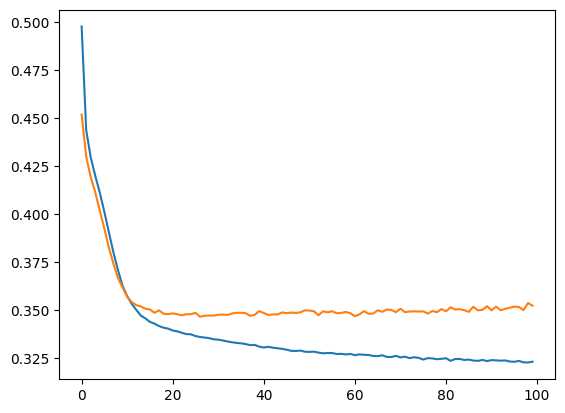

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

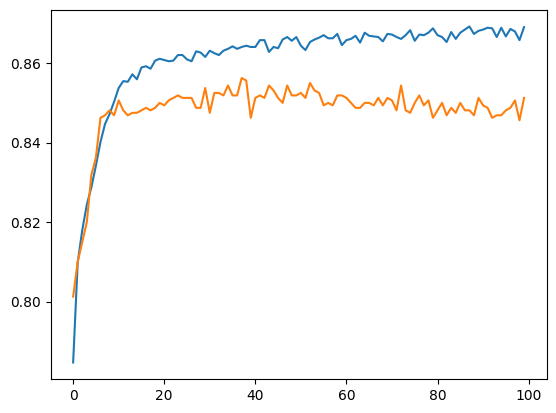

In [37]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])